<a href="https://colab.research.google.com/github/Krishishah7/ai-learning-series/blob/main/03_computer_vision/03_cnn_on_cifar10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN on CIFAR-10

CIFAR-10 is one of the most widely used datasets in Computer Vision. It contains 60,000 color images belonging to 10 different object categories.

Unlike the MNIST dataset, which contains simple handwritten digits, CIFAR-10 consists of real-world RGB images such as airplanes, automobiles, birds, cats, deer, dogs, frogs, horses, ships, and trucks.

In this notebook, we will preprocess the dataset, build a Convolutional Neural Network (CNN), train it to classify images into one of the ten categories, evaluate its performance, and visualize its predictions.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [15]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Training Images:", X_train.shape)
print("Testing Images:", X_test.shape)

Training Images: (50000, 32, 32, 3)
Testing Images: (10000, 32, 32, 3)


In [16]:
class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

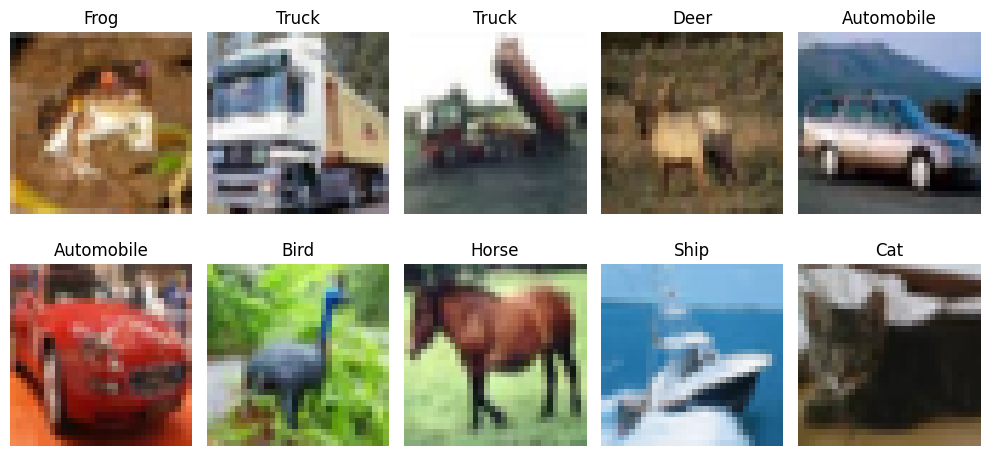

In [17]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [18]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [19]:
model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(32,32,3)),

    tf.keras.layers.Conv2D(32,(3,3),activation="relu"),

    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(64,(3,3),activation="relu"),

    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(128,(3,3),activation="relu"),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128,activation="relu"),

    tf.keras.layers.Dense(10,activation="softmax")

])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [21]:
history = model.fit(

    X_train,

    y_train,

    epochs=10,

    validation_split=0.2

)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 66s 52ms/step - accuracy: 0.4470 - loss: 1.5216 - val_accuracy: 0.5592 - val_loss: 1.2531
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 81s 51ms/step - accuracy: 0.5907 - loss: 1.1621 - val_accuracy: 0.6152 - val_loss: 1.0857
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 62s 50ms/step - accuracy: 0.6522 - loss: 0.9869 - val_accuracy: 0.6674 - val_loss: 0.9495
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 64s 51ms/step - accuracy: 0.6991 - loss: 0.8624 - val_accuracy: 0.6799 - val_loss: 0.9172
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 63s 51ms/step - accuracy: 0.7314 - loss: 0.7663 - val_accuracy: 0.6908 - val_loss: 0.8907
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 63s 50ms/step - accuracy: 0.7592 - loss: 0.6852 - val_accuracy: 0.7054 - val_loss: 0.8838
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 83s 51ms/step - accuracy: 0.7879 - loss: 0.6025 - val_accuracy: 0.7157 - val_loss: 0.8583
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 63s 51ms/step - accuracy: 0.8112 -

In [22]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7102 - loss: 1.0092
Test Loss: 1.009216070175171
Test Accuracy: 0.7102000117301941


In [23]:
predictions = model.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


In [24]:
results = pd.DataFrame({

    "Actual": [class_names[i[0]] for i in y_test[:10]],

    "Predicted": [class_names[i] for i in predicted_labels[:10]]

})

results

,Actual,Predicted
0,Cat,Cat
1,Ship,Ship
2,Ship,Automobile
3,Airplane,Airplane
4,Frog,Deer
5,Frog,Frog
6,Automobile,Automobile
7,Frog,Frog
8,Cat,Cat
9,Automobile,Automobile


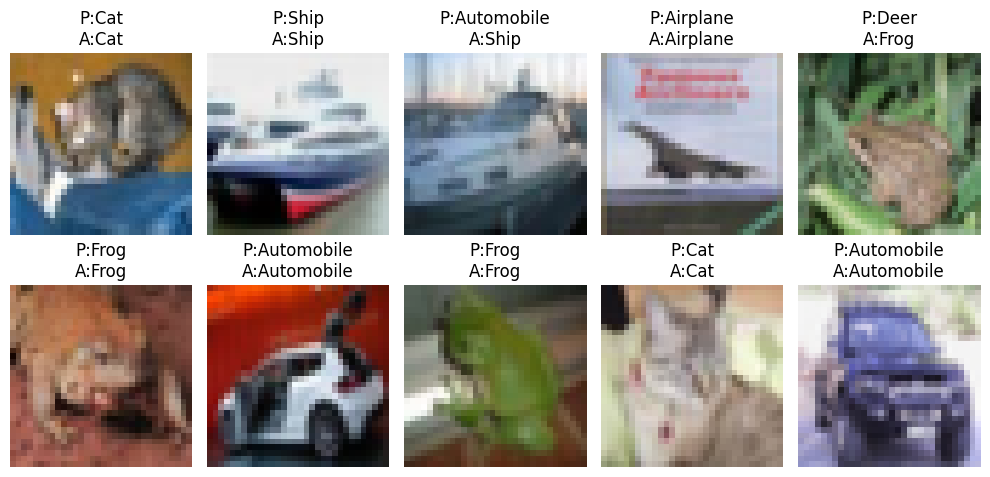

In [25]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i])
    plt.title(f"P:{class_names[predicted_labels[i]]}\nA:{class_names[y_test[i][0]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

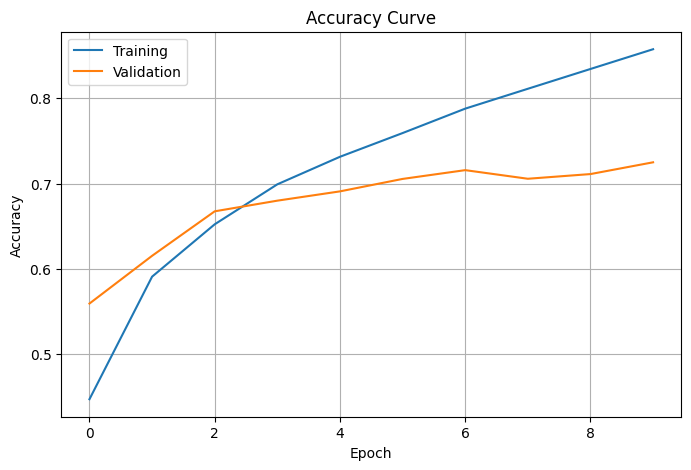

In [26]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training")
plt.plot(history.history["val_accuracy"], label="Validation")

plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()

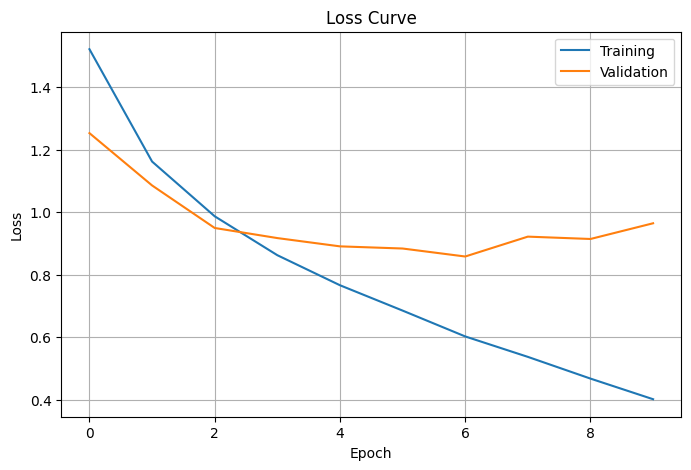

In [27]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training")
plt.plot(history.history["val_loss"], label="Validation")

plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()